# Read the data

In [1]:
#Read the data

import pandas as pd
import numpy as np

##############################################################################################
#No prediction methode
##############################################################################################

df_no_pred = pd.read_csv("df_no_pred.csv")

Idx_pred =int(len(df_no_pred[df_no_pred["Product"]==0])/2) #set prediction index

# Remove separator rows first
df_no_pred = df_no_pred.dropna(subset=["Product"])

# Convert integer columns back
int_cols = [
    "Product", "time", "theft", "Price",
    "stock", "sold", "Rest",
    "prod_max", "prod_min", "max_delivery",
    "stock missing (C_M+P_M_C)", "Double scanned",
    "Colli extra (EX_C+P_M_C)", "actual_stock", 
    "Colli", "day rest correctie", "stock correctie",
    "zerotelling","Delivery time", "delivery_amount",
    "stock_q10", "stock_q50", "stock_q90",
]

df_no_pred[int_cols] = df_no_pred[int_cols].astype(int)


##############################################################################################
#Pmf methode
##############################################################################################
df_pmf_q50 = pd.read_csv("df_pmf_q50.csv")

# Remove separator rows first
df_pmf_q50 = df_pmf_q50.dropna(subset=["Product"])

# Convert integer columns back
int_cols = [
    "Product", "time", "theft", "Price",
    "stock", "sold", "Rest",
    "prod_max", "prod_min", "max_delivery",
    "stock missing (C_M+P_M_C)", "Double scanned",
    "Colli extra (EX_C+P_M_C)", "actual_stock", 
    "Colli", "day rest correctie", "stock correctie",
    "zerotelling","Delivery time", "delivery_amount",
    "stock_q10", "stock_q50", "stock_q90",
]

df_pmf_q50[int_cols] = df_pmf_q50[int_cols].astype(int)



##############################################################################################
#Dirichlet methode pred(q50)
##############################################################################################

df_dir_q10 = pd.read_csv("df_dir_q10.csv")

# Remove separator rows first
df_dir_q10 = df_dir_q10.dropna(subset=["Product"])

# Convert integer columns back
int_cols = [
    "Product", "time", "theft", "Price",
    "stock", "sold", "Rest",
    "prod_max", "prod_min", "max_delivery",
    "stock missing (C_M+P_M_C)", "Double scanned",
    "Colli extra (EX_C+P_M_C)", "actual_stock", 
    "Colli", "day rest correctie", "stock correctie",
    "zerotelling","Delivery time", "delivery_amount",
    "stock_q10", "stock_q50", "stock_q90",
]

df_dir_q10[int_cols] = df_dir_q10[int_cols].astype(int)


##############################################################################################
#Dirichlet methode pred(q50)
##############################################################################################

df_dir_q50 = pd.read_csv("df_dir_q50.csv")

# Remove separator rows first
df_dir_q50 = df_dir_q50.dropna(subset=["Product"])

# Convert integer columns back
int_cols = [
    "Product", "time", "theft", "Price",
    "stock", "sold", "Rest",
    "prod_max", "prod_min", "max_delivery",
    "stock missing (C_M+P_M_C)", "Double scanned",
    "Colli extra (EX_C+P_M_C)", "actual_stock", 
    "Colli", "day rest correctie", "stock correctie",
    "zerotelling","Delivery time", "delivery_amount",
    "stock_q10", "stock_q50", "stock_q90",
]

df_dir_q50[int_cols] = df_dir_q50[int_cols].astype(int)


# Plotting

In [2]:
# df_no_pred[df_no_pred["Product"]==0]["stock correctie"] 
# df_no_pred[df_no_pred["Product"]==0]["zerotelling"]
# df_no_pred[df_no_pred["Product"]==0]["day rest correctie"]

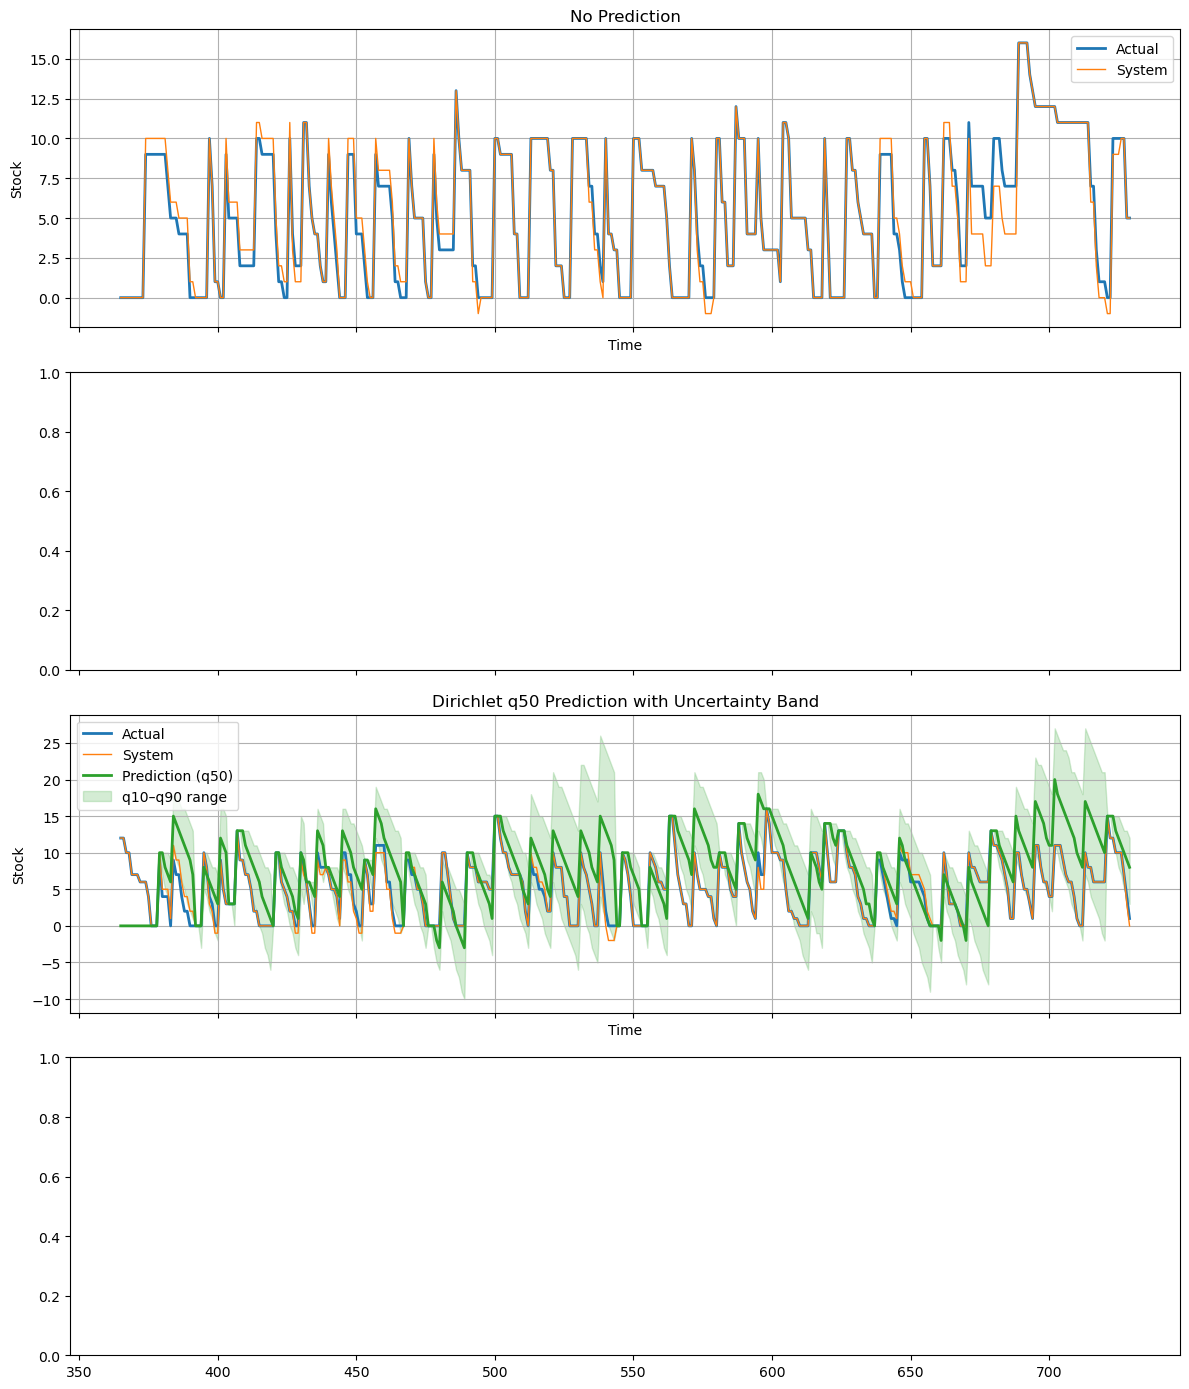

In [10]:
import matplotlib.pyplot as plt

def plot_prediction_panel(ax, df, product_id, Idx_pred, title, has_quantiles=True):
    plot_df = df[df["Product"] == product_id].copy()

    base_cols = ["actual_stock", "stock"]
    q_cols = ["stock_q10", "stock_q50", "stock_q90"]

    cols = base_cols + q_cols if has_quantiles else base_cols

    for col in cols:
        if col in plot_df.columns:
            plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    x = np.arange(len(plot_df))

    ax.plot(
        x[Idx_pred:],
        plot_df["actual_stock"].iloc[Idx_pred:],
        label="Actual",
        linewidth=2
    )

    ax.plot(
        x[Idx_pred:],
        plot_df["stock"].iloc[Idx_pred:],
        label="System",
        linewidth=1
    )

    if has_quantiles:
        line_q50, = ax.plot(
            x[Idx_pred:],
            plot_df["stock_q50"].iloc[Idx_pred:],
            label="Prediction (q50)",
            linewidth=2
        )

        color = line_q50.get_color()

        ax.fill_between(
            x[Idx_pred:],
            plot_df["stock_q10"].iloc[Idx_pred:].to_numpy(dtype=float),
            plot_df["stock_q90"].iloc[Idx_pred:].to_numpy(dtype=float),
            color=color,
            alpha=0.2,
            label="q10–q90 range"
        )

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Stock")
    ax.grid(True)
    ax.legend()


product_id = 11

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

plot_prediction_panel(
    axes[0],
    df_no_pred,
    product_id,
    Idx_pred,
    title="No Prediction",
    has_quantiles=False
)

# plot_prediction_panel(
#     axes[1],
#     df_pmf_q50,
#     product_id,
#     Idx_pred,
#     title="PMF q50 Prediction with Uncertainty Band",
#     has_quantiles=True
# )

plot_prediction_panel(
    axes[2],
    df_dir_q50,
    product_id,
    Idx_pred,
    title="Dirichlet q50 Prediction with Uncertainty Band",
    has_quantiles=True
)

# plot_prediction_panel(
#     axes[3],
#     df_dir_q10,
#     product_id,
#     Idx_pred,
#     title="Dirichlet q10 Prediction with Uncertainty Band",
#     has_quantiles=True
# )

plt.tight_layout()
plt.show()

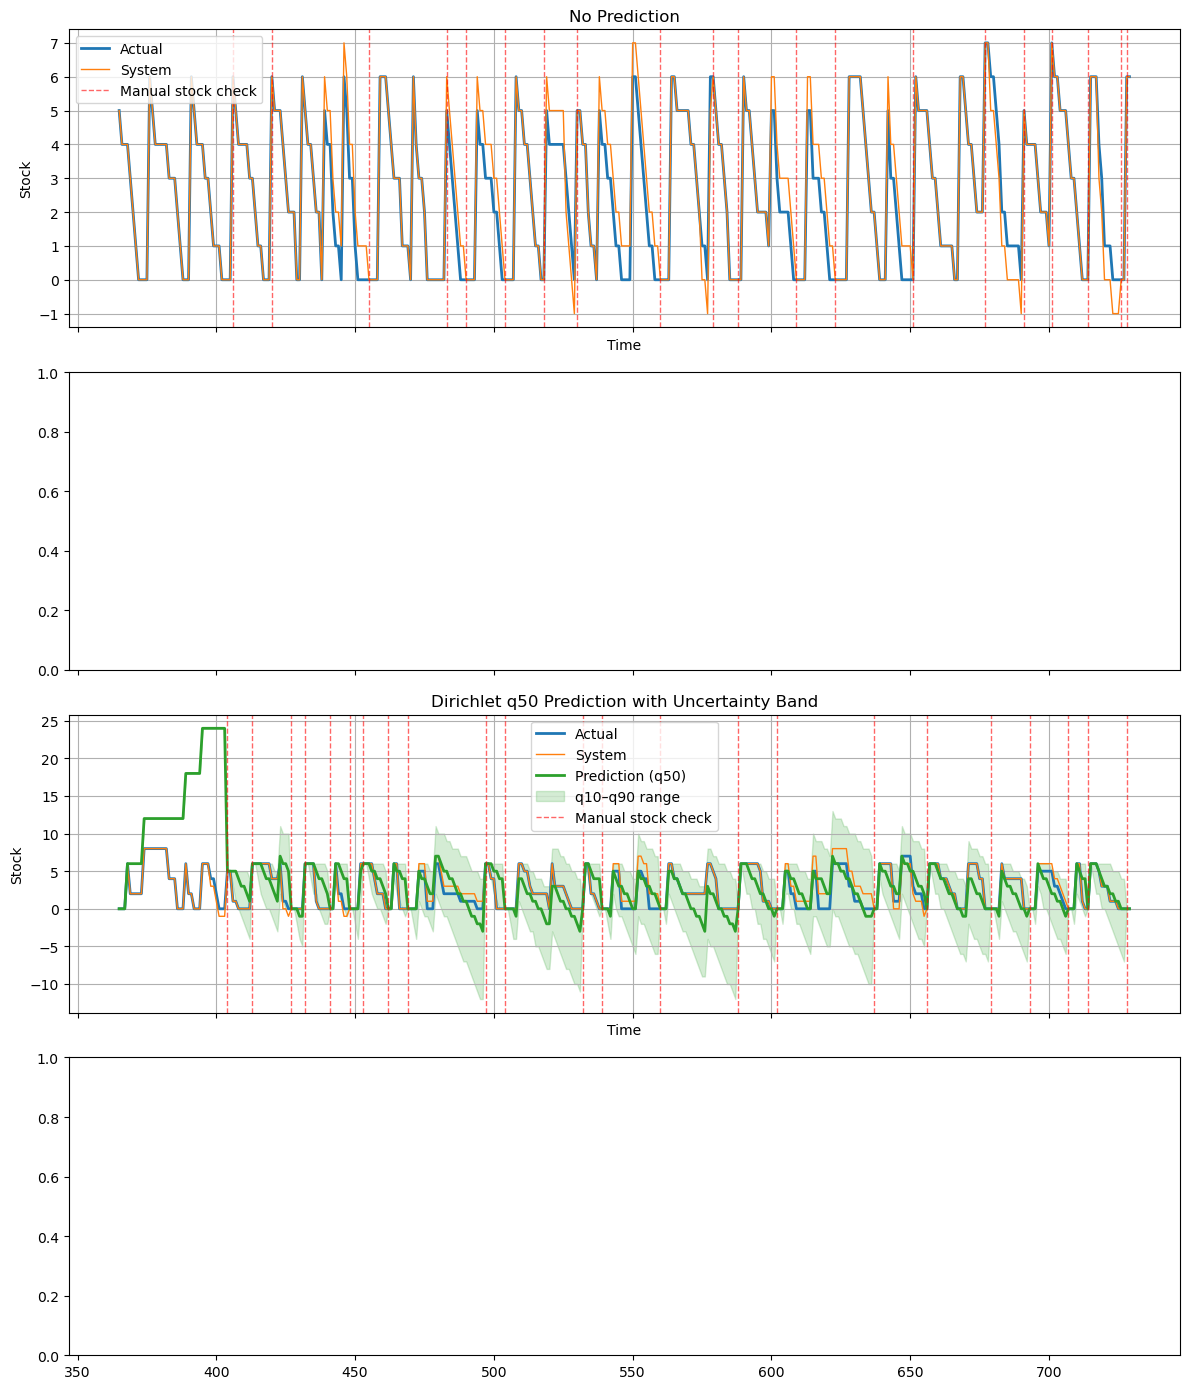

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_prediction_panel(
    ax,
    df,
    product_id,
    Idx_pred,
    title,
    has_quantiles=True,
    event_cols=("stock correctie", "zerotelling", "day rest correctie")
):
    plot_df = df[df["Product"] == product_id].copy()

    base_cols = ["actual_stock", "stock"]
    q_cols = ["stock_q10", "stock_q50", "stock_q90"]
    cols = base_cols + q_cols if has_quantiles else base_cols

    for col in cols:
        if col in plot_df.columns:
            plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    x = np.arange(len(plot_df))

    ax.plot(
        x[Idx_pred:],
        plot_df["actual_stock"].iloc[Idx_pred:],
        label="Actual",
        linewidth=2
    )

    ax.plot(
        x[Idx_pred:],
        plot_df["stock"].iloc[Idx_pred:],
        label="System",
        linewidth=1
    )

    if has_quantiles:
        line_q50, = ax.plot(
            x[Idx_pred:],
            plot_df["stock_q50"].iloc[Idx_pred:],
            label="Prediction (q50)",
            linewidth=2
        )

        color = line_q50.get_color()

        ax.fill_between(
            x[Idx_pred:],
            plot_df["stock_q10"].iloc[Idx_pred:].to_numpy(dtype=float),
            plot_df["stock_q90"].iloc[Idx_pred:].to_numpy(dtype=float),
            color=color,
            alpha=0.2,
            label="q10–q90 range"
        )

    # Add vertical event lines (merged, single style)
    event_cols = ["stock correctie", "zerotelling", "day rest correctie"]
    
    # Combine all event columns into one mask
    event_mask = np.zeros(len(plot_df), dtype=bool)
    
    for col in event_cols:
        if col in plot_df.columns:
            event_mask |= plot_df[col].fillna(0).astype(int).to_numpy() == 1
    
    # Only from Idx_pred onward
    event_positions = x[event_mask & (x >= Idx_pred)]
    
    # Plot vertical lines
    for i, xpos in enumerate(event_positions):
        ax.axvline(
            xpos,
            color="red",
            linestyle="--",
            alpha=0.6,
            linewidth=1,
            label="Manual stock check" if i == 0 else None  # only once in legend
        )

                
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Stock")
    ax.grid(True)
    ax.legend()






product_id = 10

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

plot_prediction_panel(
    axes[0],
    df_no_pred,
    product_id,
    Idx_pred,
    title="No Prediction",
    has_quantiles=False
)

# plot_prediction_panel(
#     axes[1],
#     df_pmf_q50,
#     product_id,
#     Idx_pred,
#     title="PMF q50 Prediction with Uncertainty Band",
#     has_quantiles=True
# )

plot_prediction_panel(
    axes[2],
    df_dir_q50,
    product_id,
    Idx_pred,
    title="Dirichlet q50 Prediction with Uncertainty Band",
    has_quantiles=True
)

# plot_prediction_panel(
#     axes[3],
#     df_dir_q10,
#     product_id,
#     Idx_pred,
#     title="Dirichlet q10 Prediction with Uncertainty Band",
#     has_quantiles=True
# )

plt.tight_layout()
plt.show()

Without prediction:
Times empty stock across all products = 26.96%
Times remnants of stock across all products = 8.44%
Total remnant size = 145784.00

PMF prediction (q50):
Times empty stock across all products = 20.92%
Times remnants of stock across all products = 16.74%
Total remnant size = 452293.00

Dirichlet prediction (q10):
Times empty stock across all products = 23.77%
Times remnants of stock across all products = 15.51%
Total remnant size = 489637.00

Dirichlet prediction (q50):
Times empty stock across all products = 24.73%
Times remnants of stock across all products = 11.37%
Total remnant size = 232485.00



C:\Users\Elkri\AppData\Local\Temp\ipykernel_14468\377184081.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


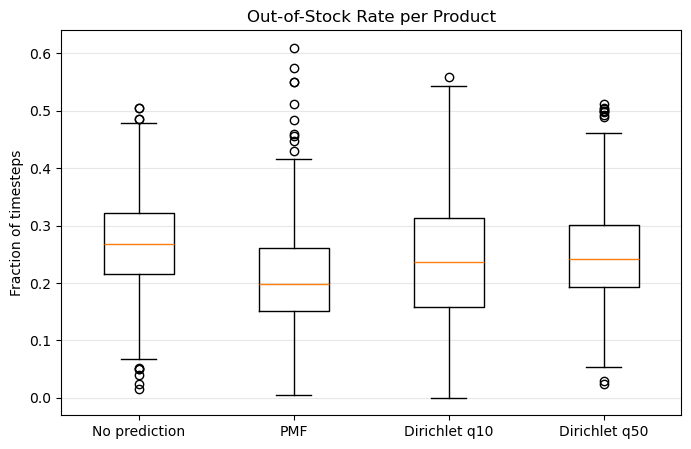

C:\Users\Elkri\AppData\Local\Temp\ipykernel_14468\377184081.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


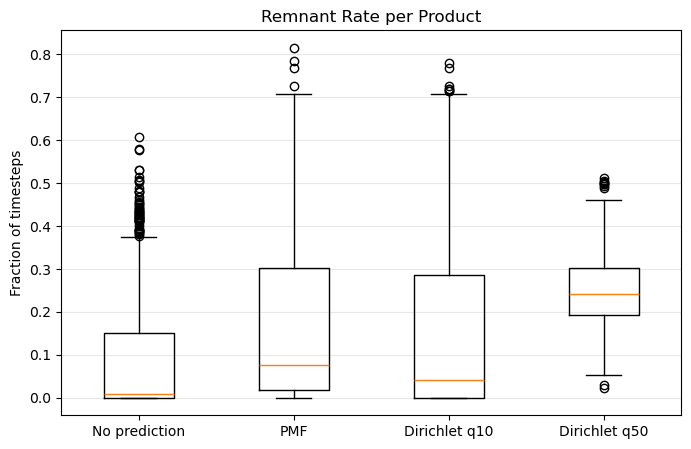

C:\Users\Elkri\AppData\Local\Temp\ipykernel_14468\377184081.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


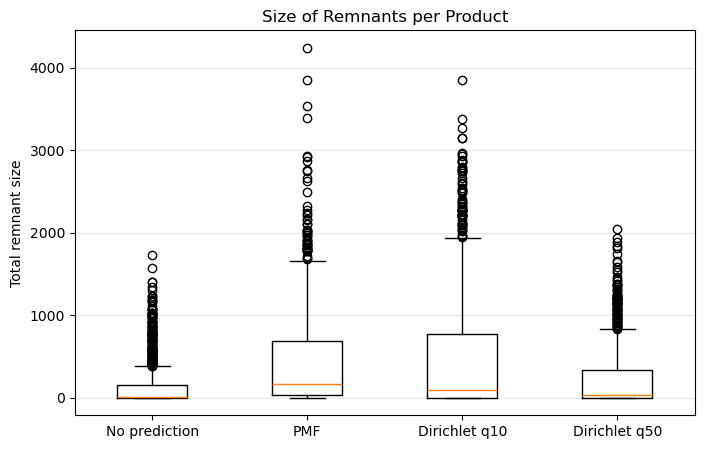

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def compute_stock_metrics(df, nr_products):
    total_timesteps = len(df["actual_stock"].values)

    cum_zero_stock = 0
    cum_t_prod_empty = []

    cum_stock_remnant = 0
    cum_t_stock_remnant = []

    cum_size_remnant = 0
    cum_t_size_remnant = []

    for i in range(nr_products):
        prod_i = df[df["Product"] == i]

        actual_stock = prod_i["actual_stock"].values
        prod_max = prod_i["prod_max"].values

        # Out of stock
        zero_stock = np.sum(actual_stock == 0)
        t_prod_empty = zero_stock / len(actual_stock)

        cum_t_prod_empty.append(t_prod_empty)
        cum_zero_stock += zero_stock

        # Remnants per timestep
        max_val = np.max(prod_max)
        stock_remnant = np.sum(actual_stock > max_val)
        t_prod_remnant = stock_remnant / len(actual_stock)

        cum_t_stock_remnant.append(t_prod_remnant)
        cum_stock_remnant += stock_remnant

        # Size of remnants
        size_remnants = actual_stock[actual_stock > max_val] - max_val
        size_remnant_sum = np.sum(size_remnants)

        cum_t_size_remnant.append(size_remnant_sum)
        cum_size_remnant += size_remnant_sum

    return {
        "empty_rate": np.array(cum_t_prod_empty),
        "remnant_rate": np.array(cum_t_stock_remnant),
        "remnant_size": np.array(cum_t_size_remnant),
        "total_empty_percent": cum_zero_stock / total_timesteps * 100,
        "total_remnant_percent": cum_stock_remnant / total_timesteps * 100,
        "total_remnant_size": cum_size_remnant,
    }


# Compute metrics
metrics_no_pred = compute_stock_metrics(df_no_pred, 1000) #nr_products
metrics_dir_q10 = compute_stock_metrics(df_dir_q10, 1000)
metrics_dir_q50 = compute_stock_metrics(df_dir_q50, 1000)
metrics_pmf_q50 = compute_stock_metrics(df_pmf_q50, 1000)

# Print comparison
def print_metrics(name, metrics):
    print(name)
    print(f"Times empty stock across all products = {metrics['total_empty_percent']:.2f}%")
    print(f"Times remnants of stock across all products = {metrics['total_remnant_percent']:.2f}%")
    print(f"Total remnant size = {metrics['total_remnant_size']:.2f}")
    print()


print_metrics("Without prediction:", metrics_no_pred)
print_metrics("PMF prediction (q50):", metrics_pmf_q50)
print_metrics("Dirichlet prediction (q10):", metrics_dir_q10)
print_metrics("Dirichlet prediction (q50):", metrics_dir_q50)



def compare_boxplot(data_no_pred, data_pmf_q50, data_dir_q10, data_dir_q50, title, ylabel):
    plt.figure(figsize=(8, 5))

    plt.boxplot(
        [data_no_pred, data_pmf_q50, data_dir_q10, data_dir_q50],
        labels=["No prediction", "PMF", "Dirichlet q10", "Dirichlet q50"])

    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


# Combined plots
compare_boxplot(
    metrics_no_pred["empty_rate"],
    metrics_pmf_q50["empty_rate"],
    metrics_dir_q10["empty_rate"],
    metrics_dir_q50["empty_rate"],
    title="Out-of-Stock Rate per Product",
    ylabel="Fraction of timesteps"
)

compare_boxplot(
    metrics_no_pred["remnant_rate"],
    metrics_pmf_q50["remnant_rate"],
    metrics_dir_q10["remnant_rate"],
    metrics_dir_q50["empty_rate"],
    title="Remnant Rate per Product",
    ylabel="Fraction of timesteps"
)

compare_boxplot(
    metrics_no_pred["remnant_size"],
    metrics_pmf_q50["remnant_size"],
    metrics_dir_q10["remnant_size"],
    metrics_dir_q50["remnant_size"],
    title="Size of Remnants per Product",
    ylabel="Total remnant size"
)

# Old

In [6]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# def plot_prediction_panel(
#     ax,
#     df,
#     product_id,
#     Idx_pred,
#     title,
#     has_quantiles=True,
#     event_cols=("stock correctie", "zerotelling", "day rest correctie")
# ):
#     plot_df = df[df["Product"] == product_id].copy()

#     base_cols = ["actual_stock", "stock"]
#     q_cols = ["stock_q10", "stock_q50", "stock_q90"]
#     cols = base_cols + q_cols if has_quantiles else base_cols

#     for col in cols:
#         if col in plot_df.columns:
#             plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

#     x = np.arange(len(plot_df))

#     ax.plot(
#         x[Idx_pred:],
#         plot_df["actual_stock"].iloc[Idx_pred:],
#         label="Actual",
#         linewidth=2
#     )

#     ax.plot(
#         x[Idx_pred:],
#         plot_df["stock"].iloc[Idx_pred:],
#         label="System",
#         linewidth=1
#     )

#     if has_quantiles:
#         line_q50, = ax.plot(
#             x[Idx_pred:],
#             plot_df["stock_q50"].iloc[Idx_pred:],
#             label="Prediction (q50)",
#             linewidth=2
#         )

#         color = line_q50.get_color()

#         ax.fill_between(
#             x[Idx_pred:],
#             plot_df["stock_q10"].iloc[Idx_pred:].to_numpy(dtype=float),
#             plot_df["stock_q90"].iloc[Idx_pred:].to_numpy(dtype=float),
#             color=color,
#             alpha=0.2,
#             label="q10–q90 range"
#         )

#     # Add vertical event lines ONLY from Idx_pred onward
#     event_styles = {
#         "stock correctie": {"color": "red", "linestyle": "--", "label": "Stock correctie"},
#         "zerotelling": {"color": "purple", "linestyle": ":", "label": "Zerotelling"},
#         "day rest correctie": {"color": "orange", "linestyle": "-.", "label": "Day rest correctie"},
#     }
    
#     used_labels = set()
    
#     for event_col in event_cols:
#         if event_col in plot_df.columns:
#             mask = plot_df[event_col].fillna(0).astype(int).to_numpy() == 1
    
#             # Only keep events from Idx_pred onward
#             event_positions = x[mask & (x >= Idx_pred)]
    
#             for xpos in event_positions:
#                 label = event_styles[event_col]["label"]
    
#                 ax.axvline(
#                     xpos,
#                     color=event_styles[event_col]["color"],
#                     linestyle=event_styles[event_col]["linestyle"],
#                     alpha=0.6,
#                     linewidth=1,
#                     label=label if label not in used_labels else None
#                 )
    
#                 used_labels.add(label)


                
#     ax.set_title(title)
#     ax.set_xlabel("Time")
#     ax.set_ylabel("Stock")
#     ax.grid(True)
#     ax.legend()